Noise Cancellation Projects

In [4]:
pip install librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 2.8 MB/s eta 0:00:003.4 MB/s eta 0:00:01m
Note: you may need to restart the kernel to use updated packages.


The problem noise of cancellation which in the process of d(n) in which estimated from a noise corrupted observation.
x(n) =  ^d(n) + ^v1(n)
Without know the d(n) and v1(n) is projects is not possible for processing.

Given a reference signal, v2(n), that is correlated with the v1(n) then the reference signal may be used to estimate the noise v1(n), then estianal my be subtract from x(n) to from an estimate the of d(n).

^d(n) =  x(n) - ^v1(n)

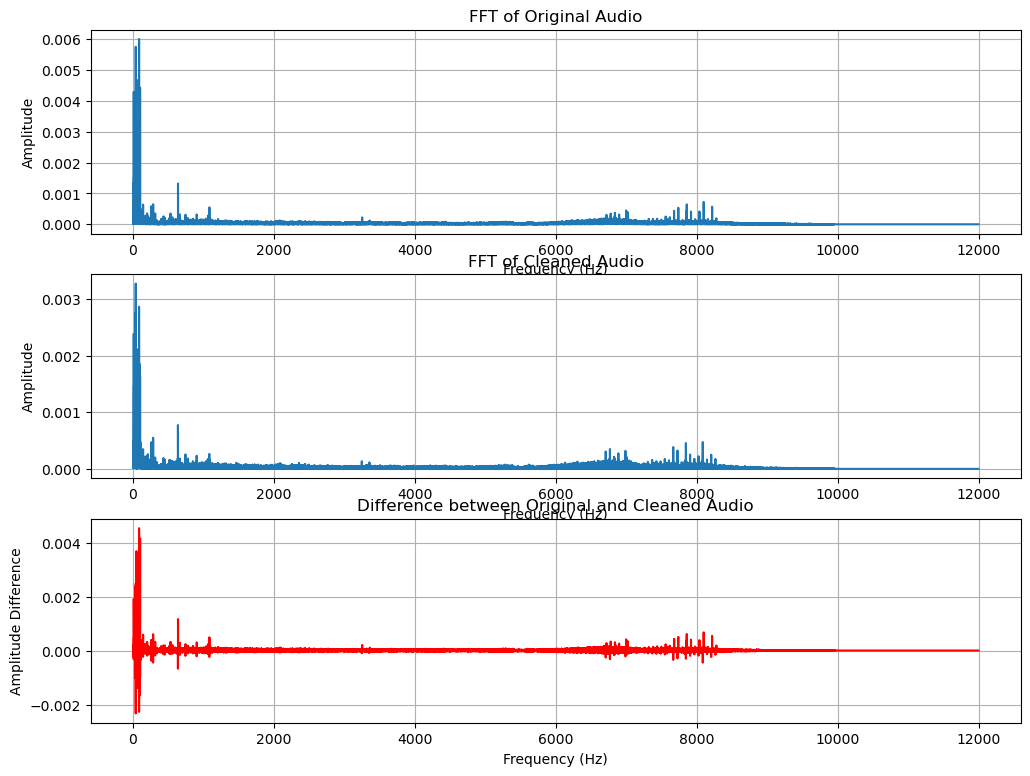

In [8]:
import numpy as np
import matplotlib.pyplot as plt  # Corrected import alias for consistency
import librosa
import scipy.fftpack as fft
from scipy.signal import medfilt
import soundfile as sf  # Added missing import for writing audio

y, sr = librosa.load('bga.mp3', sr=None)  # sr stands for the sample rate

S_full, phase = librosa.magphase(librosa.stft(y))  # Corrected: stift -> stft

noise_power = np.mean(S_full[:, :int(sr*0.1)], axis=1)  # This takes only 0.1 seconds of the audio

mask = S_full > noise_power[:, None]
mask = mask.astype(float)
mask = medfilt(mask, kernel_size=(1,5))

S_clean = S_full * mask

y_clean = librosa.istft(S_clean * phase)

sf.write("clean.wav", y_clean, sr)  # Now works with soundfile import

n = len(y)
yf = fft.fft(y)
yf_clean = fft.fft(y_clean)
xf = np.linspace(0.0, sr / 2.0, n // 2)  # Corrected: linespace -> linspace, removed invalid syntax

difference = np.abs(yf[:n // 2]) - np.abs(yf_clean[:n // 2])  # Corrected spacing for consistency

plt.figure(figsize=(12,9))

plt.subplot(3,1,1)  # Corrected: removed *args
plt.plot(xf, 2.0 / n * np.abs(yf[:n // 2]))  # Corrected: plot original yf, removed *args
plt.title('FFT of Original Audio')
plt.xlabel("Frequency (Hz)")
plt.ylabel('Amplitude')  # Corrected: ylable -> ylabel
plt.grid()

plt.subplot(3,1,2)  # Corrected: removed *args
plt.plot(xf, 2.0 / n * np.abs(yf_clean[:n // 2]))  # Corrected: removed *args
plt.title('FFT of Cleaned Audio')
plt.xlabel("Frequency (Hz)")
plt.ylabel('Amplitude')  # Corrected: ylable -> ylabel
plt.grid()


plt.subplot(3,1,3)  # Corrected: removed *args
plt.plot(xf, 2.0 / n * difference, color='red')  # Corrected: removed *args
plt.title('Difference between Original and Cleaned Audio')  # Corrected: Different -> Difference
plt.xlabel("Frequency (Hz)")
plt.ylabel('Amplitude Difference')  # Corrected: ylable -> ylabel
plt.grid()

plt.show()
